In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
pd.set_option('display.max_columns', None)

In [29]:
# def load_and_impute(file_path, target_col):
#     df = pd.read_csv(file_path)
#     print("Data Shape:", df.shape)

#     print("\nFirst 5 rows:")
#     print(df.head())

#     print("\nTarget Class Distribution:")
#     print(df[target_col].value_counts().sort_index())

#     print('Missing values: ',df.isnull().sum())
#     df.fillna(df.mean(numeric_only=True), inplace=True)

#     X = df.drop(columns=[target_col]).values
#     y = df[target_col].values
    
#     return X, y

In [30]:
def load_and_impute(file_path, target_col):
    df = pd.read_csv(file_path)
    
    num_duplicates = df.duplicated().sum()
    print(f"Original shape: {df.shape}")
    print(f"Duplicate rows found: {num_duplicates}")
    
    if num_duplicates > 0:
        df.drop_duplicates(inplace=True)
        print(f"Shape after dropping duplicates: {df.shape}")
    
    df.fillna(df.mean(numeric_only=True), inplace=True)

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    
    return X, y

In [31]:
df_path = 'heart.csv'
target_col = 'target'
X, y = load_and_impute(df_path, target_col)

Original shape: (1025, 14)
Duplicate rows found: 723
Shape after dropping duplicates: (302, 14)


In [32]:
def train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    train_idx = indices[:int(train_ratio*n_samples)]
    val_idx = indices[int(train_ratio*n_samples) : int((train_ratio+val_ratio)*n_samples)]
    test_idx = indices[int((train_ratio+val_ratio)*n_samples):]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]


X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42)

In [33]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    

scaler = standardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [34]:
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1, [[tn, fp], [fn, tp]]    

In [35]:
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [36]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.value = value
        self.right = right
        self.left = left

In [37]:
class DecisionTree:
    def __init__(self, max_depth=1):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y, sample_weights=None):
        n_samples = X.shape[0]
        if sample_weights is None:
            sample_weights = np.ones(n_samples) / n_samples
        
        self.root = self._grow_tree(X, y, sample_weights, depth=0)

    def _grow_tree(self, X, y, sample_weights, depth=0):
        n_samples, n_feat = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels == 1 or n_samples < 2):
            leaf_value = self._most_common_label(y, sample_weights)
            return Node(value=leaf_value)
        
        feat_idxs = range(n_feat)
        
        best_feat, best_thresh = self._best_split(X, y, sample_weights, feat_idxs)

        if best_feat is None:
            leaf_value = self._most_common_label(y, sample_weights)
            return Node(value=leaf_value)

        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], sample_weights[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], sample_weights[right_idxs], depth + 1)

        return Node(feature_idx=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, sample_weights, feat_idxs):
        best_gini = float('inf')
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thr in thresholds:
                gini = self._calculate_weighted_gini(y, X_column, thr, sample_weights)
                
                if gini < best_gini:
                    best_gini = gini
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _calculate_weighted_gini(self, y, X_column, threshold, sample_weights):
        left_idxs = X_column <= threshold
        right_idxs = X_column > threshold
        
        if sum(left_idxs) == 0 or sum(right_idxs) == 0:
            return float('inf')
            
        def weighted_gini_node(idxs):
            w_total = np.sum(sample_weights[idxs])
            if w_total == 0: return 0
            gini = 1.0
            for c in np.unique(y):
                p = np.sum(sample_weights[idxs & (y == c)]) / w_total
                gini -= p**2
            return gini

        w_left = np.sum(sample_weights[left_idxs])
        w_right = np.sum(sample_weights[right_idxs])
        w_total = w_left + w_right

        gini_left = weighted_gini_node(left_idxs)
        gini_right = weighted_gini_node(right_idxs)
        
        return (w_left / w_total) * gini_left + (w_right / w_total) * gini_right

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y, sample_weights):
        if len(y) == 0: return 0
        classes = np.unique(y)
        best_weight = -1
        best_class = None
        for cls in classes:
            w = np.sum(sample_weights[y == cls])
            if w > best_weight:
                best_weight = w
                best_class = cls
        return best_class

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

In [38]:
class AdaBoost:
    def __init__(self, n_estimators=50, max_depth=1, patience=3):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.patience = patience
        self.models = []
        self.alphas = []
        self.train_errors = []
        self.val_errors = []

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_samples = X_train.shape[0]
        weights = np.full(n_samples, 1 / n_samples)
        
        self.models = []
        self.alphas = []
        self.train_errors = []
        self.val_errors = []

        best_val_error = float('inf')
        patience_counter = 0

        for t in range(self.n_estimators):
            model = DecisionTree(max_depth=self.max_depth)
            model.fit(X_train, y_train, sample_weights=weights)
            
            predictions = model.predict(X_train)
            error = np.sum(weights[predictions != y_train])
            
            epsilon = 1e-10
            if error >= 0.5:
                break
            if error == 0:
                alpha = 5.0
            else:
                alpha = 0.5 * np.log((1 - error) / (error + epsilon))

            self.models.append(model)
            self.alphas.append(alpha)

            matches = (predictions == y_train)
            weights[matches] *= np.exp(-alpha)
            weights[~matches] *= np.exp(alpha)
            weights /= np.sum(weights)

            if X_val is not None and y_val is not None:
                val_preds = self.predict(X_val)
                val_acc = accuracy_score(y_val, val_preds)
                val_error = 1 - val_acc
                self.val_errors.append(val_error)

                if val_error > best_val_error:
                    patience_counter += 1
                else:
                    best_val_error = val_error
                    patience_counter = 0
                
                if patience_counter >= self.patience:
                    break

    def predict(self, X):
        if not self.models:
            return np.zeros(X.shape[0])
         
        model_preds = np.array([model.predict(X) for model in self.models])

        model_preds_signed = np.where(model_preds == 0, -1, 1)

        weighted_sums = np.dot(self.alphas, model_preds_signed)

        final_predictions = np.where(weighted_sums >= 0, 1, 0)

        return final_predictions


10/250: Trees: 2, Depth: 1 -> Train Acc: 0.7593 | Val Acc: 0.6967
20/250: Trees: 2, Depth: 3 -> Train Acc: 0.8469 | Val Acc: 0.7833
30/250: Trees: 2, Depth: 5 -> Train Acc: 0.9154 | Val Acc: 0.7267
40/250: Trees: 2, Depth: 7 -> Train Acc: 0.9793 | Val Acc: 0.7600
50/250: Trees: 2, Depth: 9 -> Train Acc: 0.9992 | Val Acc: 0.7567
60/250: Trees: 5, Depth: 1 -> Train Acc: 0.8373 | Val Acc: 0.8033
70/250: Trees: 5, Depth: 3 -> Train Acc: 0.9282 | Val Acc: 0.7967
80/250: Trees: 5, Depth: 5 -> Train Acc: 0.9963 | Val Acc: 0.7767
90/250: Trees: 5, Depth: 7 -> Train Acc: 1.0000 | Val Acc: 0.7900
100/250: Trees: 5, Depth: 9 -> Train Acc: 1.0000 | Val Acc: 0.7600
110/250: Trees: 10, Depth: 1 -> Train Acc: 0.8440 | Val Acc: 0.7900
120/250: Trees: 10, Depth: 3 -> Train Acc: 0.9502 | Val Acc: 0.7667
130/250: Trees: 10, Depth: 5 -> Train Acc: 0.9963 | Val Acc: 0.7433
140/250: Trees: 10, Depth: 7 -> Train Acc: 1.0000 | Val Acc: 0.7900
150/250: Trees: 10, Depth: 9 -> Train Acc: 1.0000 | Val Acc: 0.7567

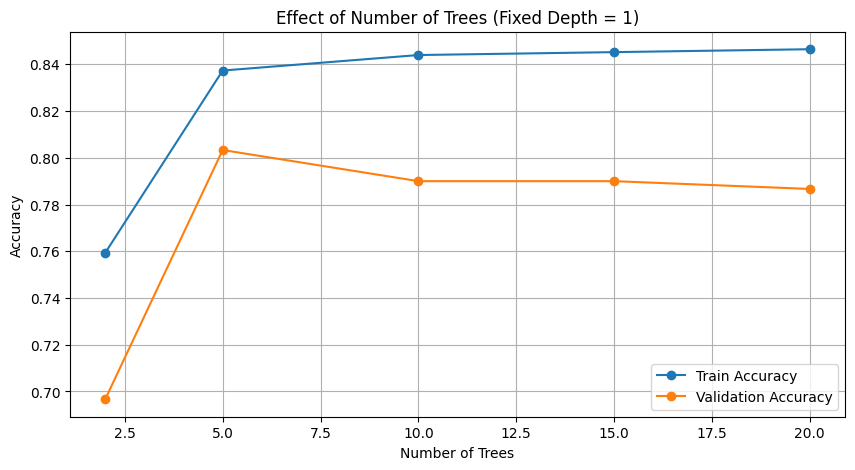

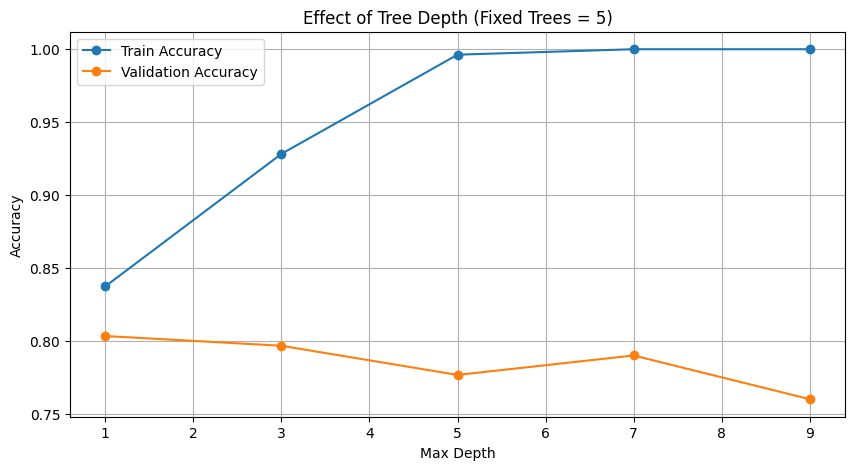


Best Model:
Accuracy: 0.7742
Precision: 0.8462
Recall: 0.6875
F1-Score: 0.7586
Confusion Matrix:
[[13  2]
 [ 5 11]]


In [39]:
n_estimators_list = [2, 5, 10, 15, 20]
max_depth_list = [1, 3, 5, 7, 9]
seeds = range(10)
results = []

total_combos = len(n_estimators_list) * len(max_depth_list) * len(seeds)
current_combo = 0

for n_est in n_estimators_list:
    for depth in max_depth_list:
        
        val_accuracies = []
        train_accuracies = []
        
        for seed in seeds:
            current_combo += 1
            X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(
                X, y, train_ratio=0.8, val_ratio=0.1, random_state=seed
            )
            
            scaler = standardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            
            clf = AdaBoost(n_estimators=n_est, max_depth=depth, patience=3)
            clf.fit(X_train, y_train, X_val, y_val)
        
            train_acc = accuracy_score(y_train, clf.predict(X_train))
            val_acc = accuracy_score(y_val, clf.predict(X_val))
            
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)
            
        avg_train_acc = np.mean(train_accuracies)
        avg_val_acc = np.mean(val_accuracies)
        
        print(f"{current_combo}/{total_combos}: Trees: {n_est}, Depth: {depth} -> Train Acc: {avg_train_acc:.4f} | Val Acc: {avg_val_acc:.4f}")
        
        results.append({
            'n_estimators': n_est,
            'max_depth': depth,
            'avg_train_acc': avg_train_acc,
            'avg_val_acc': avg_val_acc
        })

        results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df['avg_val_acc'].idxmax()]
best_depth = int(best_row['max_depth'])
best_n_est = int(best_row['n_estimators'])

print("\n" + "="*30)
print(f"Best Model:")
print(f"Depth: {best_depth}")
print(f"Number of Trees: {best_n_est}")
print(f"Validation Accuracy: {best_row['avg_val_acc']:.4f}")
print("="*30 + "\n")

subset_trees = results_df[results_df['max_depth'] == best_depth]

plt.figure(figsize=(10, 5))
plt.plot(subset_trees['n_estimators'], subset_trees['avg_train_acc'], marker='o', label='Train Accuracy')
plt.plot(subset_trees['n_estimators'], subset_trees['avg_val_acc'], marker='o', label='Validation Accuracy')
plt.title(f'Effect of Number of Trees (Fixed Depth = {best_depth})')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

subset_depth = results_df[results_df['n_estimators'] == best_n_est]

plt.figure(figsize=(10, 5))
plt.plot(subset_depth['max_depth'], subset_depth['avg_train_acc'], marker='o', label='Train Accuracy')
plt.plot(subset_depth['max_depth'], subset_depth['avg_val_acc'], marker='o', label='Validation Accuracy')
plt.title(f'Effect of Tree Depth (Fixed Trees = {best_n_est})')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, random_state=42)
scaler = standardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

final_model = AdaBoost(n_estimators=best_n_est, max_depth=best_depth, patience=3)
final_model.fit(X_train, y_train, X_val=scaler.transform(X_val), y_val=y_val)
y_pred_test = final_model.predict(X_test)

acc, prec, rec, f1, cm = calculate_metrics(y_test, y_pred_test)

print("\nBest Model:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:")
print(np.array(cm))

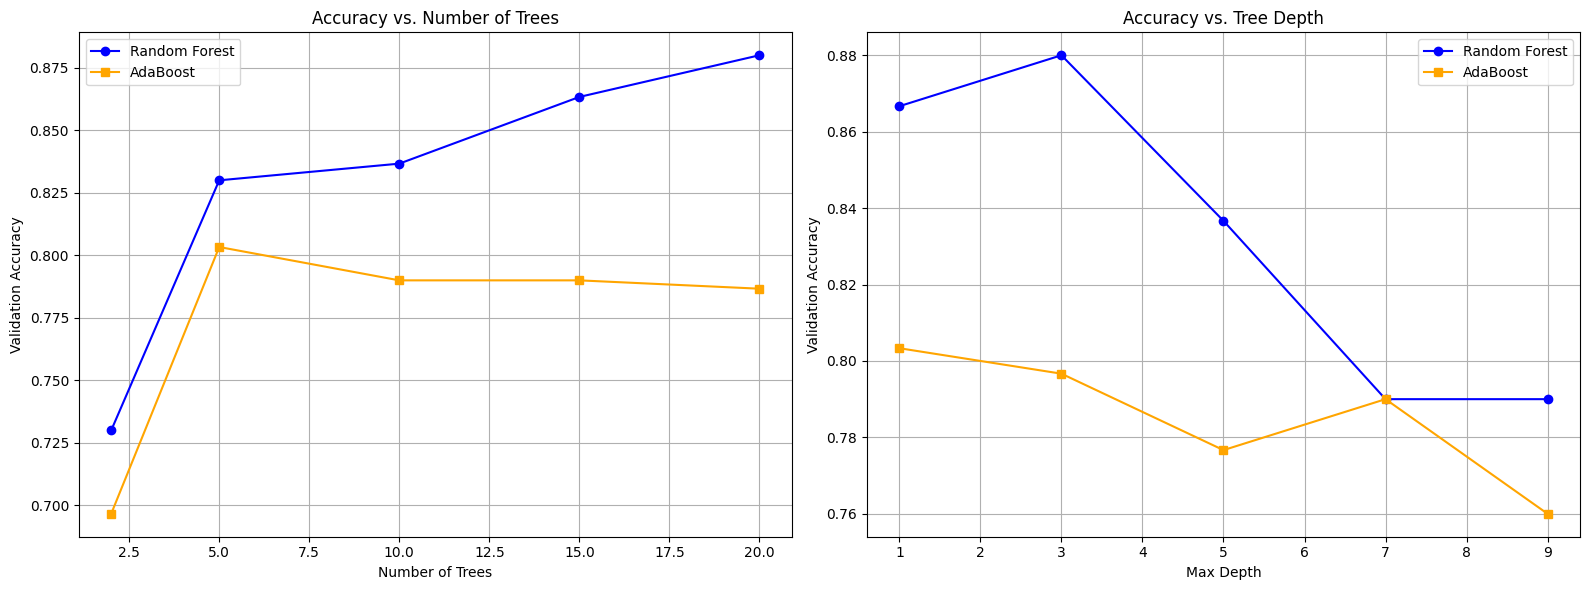

In [40]:
ada_acc_trees_list = subset_trees.sort_values('n_estimators')['avg_val_acc'].tolist()
ada_acc_depth_list = subset_depth.sort_values('max_depth')['avg_val_acc'].tolist()

rf_acc_trees = [0.7300000000000001, 0.8300000000000001, 0.8366666666666667, 0.8633333333333333, 0.8799999999999999]
rf_acc_depth = [0.8666666666666666, 0.8799999999999999, 0.8366666666666667, 0.79, 0.79]
    
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_trees = [2, 5, 10, 15, 20]
x_depth = [1, 3, 5, 7, 9]

axes[0].plot(x_trees, rf_acc_trees, 'o-', label='Random Forest', color='blue')
axes[0].plot(x_trees, ada_acc_trees_list, 's-', label='AdaBoost', color='orange')
axes[0].set_title('Accuracy vs. Number of Trees')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_depth, rf_acc_depth, 'o-', label='Random Forest', color='blue')
axes[1].plot(x_depth, ada_acc_depth_list, 's-', label='AdaBoost', color='orange')
axes[1].set_title('Accuracy vs. Tree Depth')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()